In [ ]:
# Paramdeep Choudhary
# cu24250162
# labsheet 08


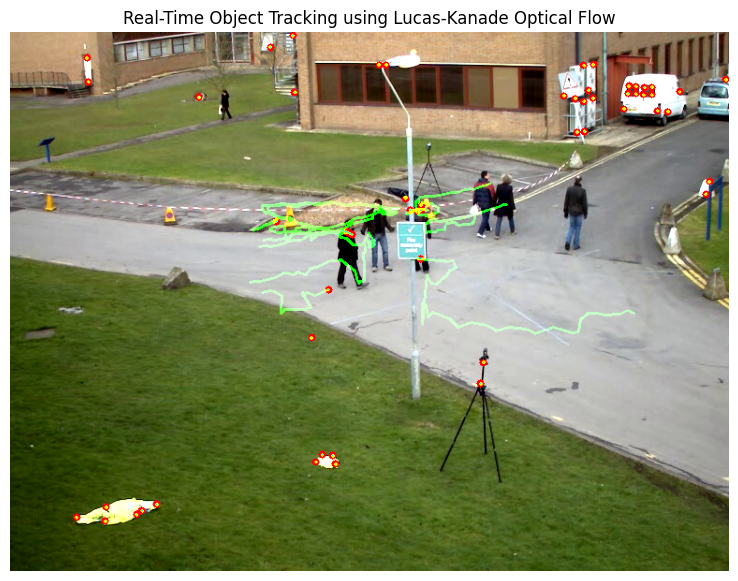

Object Tracking Completed Successfully!
Frames Processed: 100
Average Feature Displacement: 0.43 pixels


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

video_url = "https://github.com/opencv/opencv/raw/4.x/samples/data/vtest.avi"
video_path = "vtest.avi"

!wget -q {video_url} -O {video_path}

cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

if not ret:
    print("Error: Could not read video.")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    feature_params = dict(
        maxCorners=100,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    lk_params = dict(
        winSize=(15, 15),
        maxLevel=2,
        criteria=(
            cv2.TERM_CRITERIA_EPS |
            cv2.TERM_CRITERIA_COUNT,
            10,
            0.03
        )
    )

    p0 = cv2.goodFeaturesToTrack(
        old_gray,
        mask=None,
        **feature_params
    )

    mask = np.zeros_like(old_frame)

    frame_count = 0
    total_displacement = 0
    motion_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if p0 is not None and len(p0) > 0:

            p1, st, err = cv2.calcOpticalFlowPyrLK(
                old_gray,
                frame_gray,
                p0,
                None,
                **lk_params
            )

            if p1 is not None:
                good_new = p1[st == 1]
                good_old = p0[st == 1]

                for new, old in zip(good_new, good_old):

                    x_new, y_new = new.ravel()
                    x_old, y_old = old.ravel()

                    dx = x_new - x_old
                    dy = y_new - y_old

                    magnitude = np.sqrt(dx**2 + dy**2)

                    if magnitude > 0:
                        angle = np.degrees(
                            np.arctan2(dy, dx)
                        )

                        total_displacement += magnitude
                        motion_count += 1

                    mask = cv2.line(
                        mask,
                        (int(x_new), int(y_new)),
                        (int(x_old), int(y_old)),
                        (0, 255, 0),
                        2
                    )

                    frame = cv2.circle(
                        frame,
                        (int(x_new), int(y_new)),
                        4,
                        (0, 0, 255),
                        -1
                    )

                    frame = cv2.arrowedLine(
                        frame,
                        (int(x_old), int(y_old)),
                        (int(x_new), int(y_new)),
                        (255, 0, 0),
                        1,
                        tipLength=0.3
                    )

                output = cv2.add(frame, mask)

                p0 = good_new.reshape(-1, 1, 2)

            else:
                output = frame.copy()
                p0 = cv2.goodFeaturesToTrack(
                    frame_gray,
                    mask=None,
                    **feature_params
                )

        else:
            output = frame.copy()
            p0 = cv2.goodFeaturesToTrack(
                frame_gray,
                mask=None,
                **feature_params
            )

        old_gray = frame_gray.copy()

        output_rgb = cv2.cvtColor(
            output,
            cv2.COLOR_BGR2RGB
        )

        clear_output(wait=True)

        plt.figure(figsize=(12, 7))
        plt.imshow(output_rgb)
        plt.axis("off")
        plt.title("Real-Time Object Tracking using Lucas-Kanade Optical Flow")
        plt.show()

        if frame_count >= 100:
            break

    cap.release()

    print("Object Tracking Completed Successfully!")
    print("Frames Processed:", frame_count)

    if motion_count > 0:
        average_displacement = (
            total_displacement / motion_count
        )

        print(
            "Average Feature Displacement:",
            round(average_displacement, 2),
            "pixels"
        )
    else:
        print("No significant motion detected.")


In [ ]:
# Experiment No. 8
# Application of Optical Flow for Real-Time Object Tracking and Motion Analysis

# Q1. How does object tracking differ from object detection?
# Object detection identifies objects and their locations in individual frames.
# Object tracking follows the same object across multiple consecutive frames.
# Detection determines what and where an object is, while tracking determines
# how the object moves over time.

# Q2. Explain how Optical Flow can be used for real-time object tracking.
# Optical Flow estimates the movement of pixels or feature points between
# consecutive video frames.
# Feature points can be detected using methods such as Shi-Tomasi Corner Detection.
# Lucas-Kanade Optical Flow can then track these points from one frame to another.
# The tracked points can be used to determine the object's trajectory,
# direction, and displacement.

# Q3. What is the role of Shi-Tomasi Corner Detection in the Lucas-Kanade Optical Flow algorithm?
# Shi-Tomasi Corner Detection identifies strong and distinctive feature points
# in an image.
# These feature points are suitable for tracking because their local image
# structure can be identified reliably.
# Lucas-Kanade Optical Flow tracks these selected points between consecutive frames.

# Q4. Why is Optical Flow suitable for motion analysis in videos?
# Optical Flow provides information about the movement of objects between frames.
# It can estimate the direction and magnitude of motion.
# It can be applied continuously to video sequences.
# It is useful for tracking objects, analyzing trajectories, detecting motion,
# and understanding dynamic scenes.

# Q5. What challenges arise while tracking fast-moving or partially occluded objects?
# Fast-moving objects can produce large changes between consecutive frames.
# Motion blur can make feature points difficult to track.
# Partial occlusion can cause tracked points to disappear.
# Changes in lighting can affect feature detection.
# Objects with few visual features can also be difficult to track.
# Camera movement can introduce additional motion into the optical flow.

# Q6. Compare Optical Flow-based tracking with deep learning-based object tracking methods.
# Optical Flow-based tracking mainly uses motion information between consecutive frames.
# It can work without training a deep learning model and generally requires
# fewer computational resources.
# Deep learning-based tracking methods can use learned visual features and
# object appearance to maintain object identity.
# Deep learning methods can be more robust in complex scenes but usually
# require more computational resources and training data.
# Optical Flow is useful when motion estimation is the main requirement,
# while deep learning methods are useful when object identity and recognition
# are also important.

# Q7. How can Optical Flow be used in traffic monitoring and autonomous driving systems?
# In traffic monitoring, Optical Flow can estimate the movement of vehicles,
# pedestrians, and other road users.
# It can help measure traffic flow, direction, and movement patterns.
# In autonomous driving, optical flow can provide information about the
# relative movement of surrounding objects and help estimate scene motion.
# It can also assist in detecting moving obstacles and understanding road scenes.

# Q8. Explain the effect of camera motion on Optical Flow estimation.
# Camera movement causes many or most pixels in the scene to appear to move.
# Therefore, the optical flow may represent camera motion as well as object motion.
# Camera rotation, translation, and vibration can affect the estimated motion.
# Camera motion can make it difficult to distinguish moving objects from
# stationary objects.
# Camera-motion compensation or background motion estimation can be used
# to reduce this problem.

# Q9. Mention five real-world applications where motion analysis using Optical Flow is commonly employed.
# 1. Traffic monitoring.
# 2. Video surveillance.
# 3. Autonomous driving.
# 4. Sports analytics.
# 5. Human activity and gesture recognition.

# Q10. How can Optical Flow improve the performance of surveillance, robotics,
# and human activity recognition systems?
# In surveillance systems, Optical Flow can help detect and analyze moving objects.
# In robotics, it can provide information about the movement of the robot and
# surrounding objects and assist with navigation.
# In human activity recognition, motion patterns can help identify activities
# such as walking, running, waving, or other movements.
# Optical Flow provides useful temporal motion information that can complement
# object detection and other computer vision techniques.

# Conclusion:
# An optical flow-based object tracking system was successfully implemented
# using Python and OpenCV.
# Lucas-Kanade Optical Flow was used to track feature points between consecutive
# video frames and visualize their trajectories and motion directions.
# The experiment demonstrated that optical flow can provide useful motion
# information for real-time tracking and dynamic scene analysis.
